### En este jupyter se desarollaran los de aprendisaje no supervisados:
Se desarrollaran los módelos de aprendizaje no supervidado

In [2]:
# numpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
import shap
#sklearn
from sklearn.preprocessing import ( 
                                   RobustScaler
                                   )
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
                            confusion_matrix, 
                            classification_report
                            )
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, IsolationForest

## 1. Carga y Preprocesamiento

In [3]:
path = "data/datos_preparados_anomalias.csv"
df_munis = pd.read_csv(path)

In [4]:
path = "data/Data_numerical.csv"
df_munis_sup = pd.read_csv(path)

### 1.1 Scaler 

Escalamos los datos con robust scaler y escala logaritmica por las características extremas de los datos

In [5]:
#Para procesar
cols_a_transformar = ['CantidadItem', 'MontoTotalItem', 'Precio_Unitario_TOTAL', 'Monto_Total_Orden','Proveedor_freq','Institucion_freq','ActividadProveedor_freq']

# columnas nuevas para representar el log
for col in cols_a_transformar:
    df_munis[f'{col}_log'] = np.log1p(df_munis[col].astype(float))

#  robust Scaler: escala considerando las diferencias extremas dadad por los otliers 
# en los precios muy grandes
scaler = RobustScaler()

cols_finales_log = [f'{c}_log' for c in cols_a_transformar]

df_munis[cols_finales_log] = scaler.fit_transform(df_munis[cols_finales_log])

df_munis = df_munis.drop(columns=cols_a_transformar)

In [6]:
df_munis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64487 entries, 0 to 64486
Data columns (total 36 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   is_expensive                                              64487 non-null  bool   
 1   EstadoOC_En Proceso                                       64487 non-null  bool   
 2   EstadoOC_Enviada a Proveedor                              64487 non-null  bool   
 3   EstadoOC_Recepcion Conforme                               64487 non-null  bool   
 4   EstadoOC_Solicitud de Cancelacion                         64487 non-null  bool   
 5   TipoDespacho_Despachar a Dirección de envío               64487 non-null  bool   
 6   TipoDespacho_Despachar según programa adjuntado           64487 non-null  bool   
 7   TipoDespacho_Despacho por courier o encomienda terrestre  64487 non-null  bool   
 8   TipoDespacho_Otr

In [7]:
# Separar X e y
X = df_munis.drop(columns=["is_expensive"]).copy()
y = df_munis["is_expensive"].copy()

## Isolation Forest
Aplicamos el isolation fortes para encontrar outliers. Luego utilizamos validacion con la clasificacion que nosotros mismos hicimos 

In [8]:
# dividimos el conjunto, el y_test es solo para referencia 
# e identificar las similitudes con nuestra clasificación manual 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42 
)


In [9]:
iso_forest = IsolationForest(
    n_estimators=200, 
    contamination='auto',  
    random_state=42,
    n_jobs=-1
)

# entrenar el isolation forest
iso_forest.fit(X_train)

IsolationForest(n_estimators=200, n_jobs=-1, random_state=42)

In [10]:
scores = iso_forest.decision_function(X_train)

In [11]:
# Predecir sobre el set de prueba
y_pred_iso_raw = iso_forest.predict(X_test)

#transformación para evaluacióm
y_pred_iso_final = [1 if x == -1 else 0 for x in y_pred_iso_raw]

In [12]:
# evaluacion respecto a las metricz
print("Matriz de Confusión")
print(confusion_matrix(y_test, y_pred_iso_final))

print("\nReporte de Clasificación")
print(classification_report(y_test, y_pred_iso_final))

Matriz de Confusión
[[10758   843]
 [  898   399]]

Reporte de Clasificación
              precision    recall  f1-score   support

       False       0.92      0.93      0.93     11601
        True       0.32      0.31      0.31      1297

    accuracy                           0.87     12898
   macro avg       0.62      0.62      0.62     12898
weighted avg       0.86      0.87      0.86     12898



## Aqui vizualizamos la separación de las anomalías

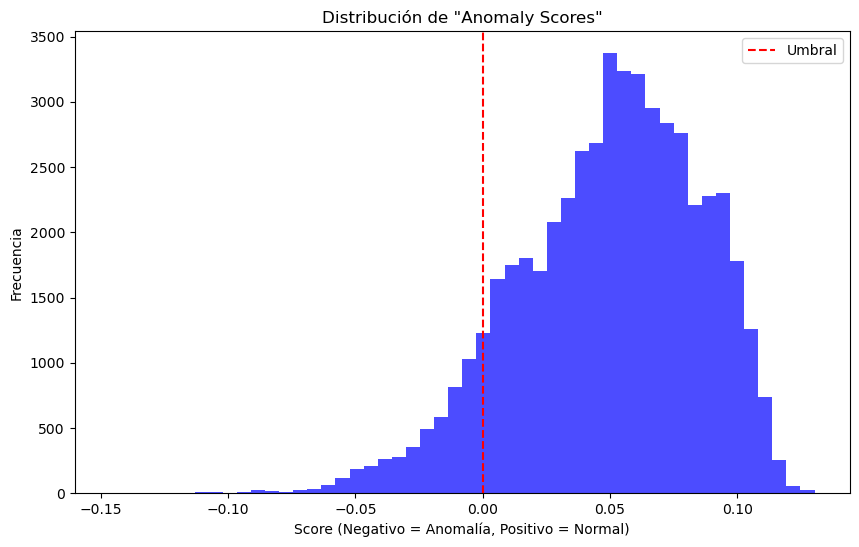

In [13]:

# Los valores negativos son anomalías, los positivos son normales
scores = iso_forest.decision_function(X_train)

# 2. Visualización de  la Separación
plt.figure(figsize=(10, 6))
plt.hist(scores, bins=50, color='blue', alpha=0.7)
plt.title('Distribución de "Anomaly Scores"')
plt.xlabel('Score (Negativo = Anomalía, Positivo = Normal)')
plt.ylabel('Frecuencia')
plt.axvline(x=0, color='red', linestyle='--', label='Umbral')
plt.legend()
plt.show()

### Queremos saber cuales son las mayores influencias en la deteccion de isolation forest

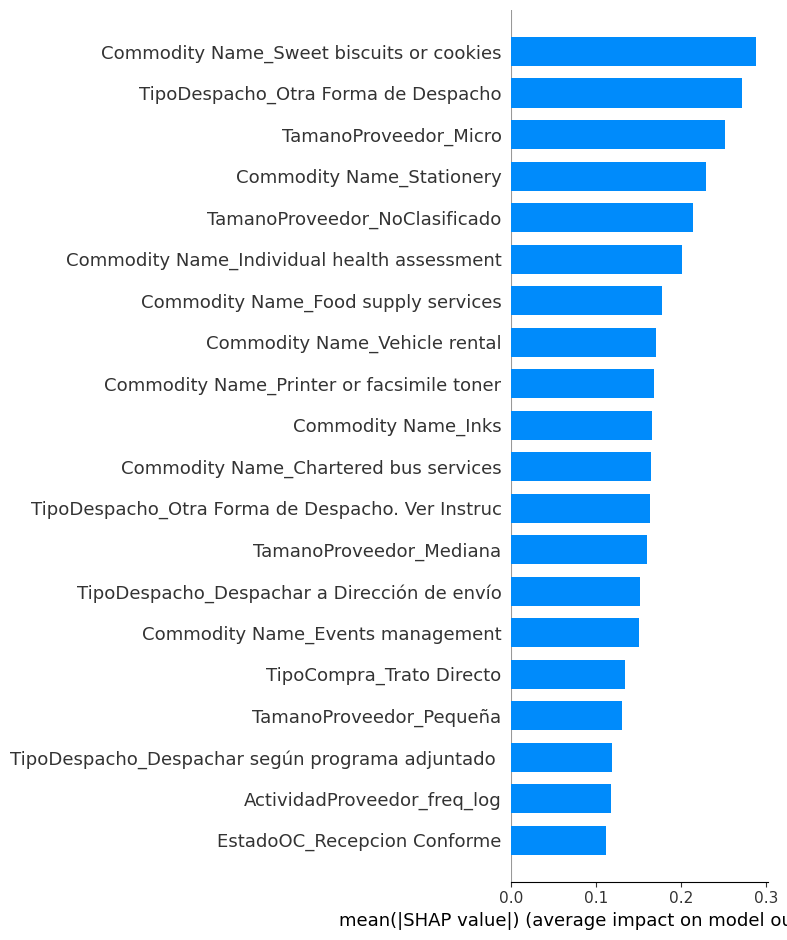

In [14]:
# explicaciones para modelos tipo  arbol
explainer = shap.TreeExplainer(iso_forest)

# calcular el shape
sample_test = X_test.iloc[:100] 
shap_values = explainer.shap_values(sample_test)

# ver el feature importance
shap.summary_plot(shap_values, sample_test, plot_type="bar")

### Isolation Forest + rf_model

In [15]:
def resultados_rf(X_train, X_test, y_train, y_test, mejor_n):
    rf = RandomForestClassifier(
        n_estimators=mejor_n,
        max_depth=7,
        max_features='sqrt',
        oob_score=True,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    )
    rf.fit(X_train, y_train)
    yhat_rf_train = rf.predict(X_train)
    yhat_rf_test = rf.predict(X_test)
    
    print('\nReporte (test):\n', classification_report(y_test, yhat_rf_test))
    print('Matriz de confusión (test):\n', confusion_matrix(y_test, yhat_rf_test))
    
    return rf



In [16]:
# con los parametros de los resultados anteriores
print("Entrenando Random Forest")
rf_model = resultados_rf(X_train, X_test, y_train, y_test, 300)

# modelo isolation
print("Entrenando Isolation Forest")
iso_model = IsolationForest(n_estimators=200, contamination='auto', random_state=42, n_jobs=-1)
iso_model.fit(X_train) 

Entrenando Random Forest

Reporte (test):
               precision    recall  f1-score   support

       False       1.00      0.94      0.97     11601
        True       0.64      0.99      0.78      1297

    accuracy                           0.94     12898
   macro avg       0.82      0.96      0.87     12898
weighted avg       0.96      0.94      0.95     12898

Matriz de confusión (test):
 [[10887   714]
 [   19  1278]]
Entrenando Isolation Forest


IsolationForest(n_estimators=200, n_jobs=-1, random_state=42)

In [17]:
pred_supervisada = rf_model.predict(X_test)
pred_iso_raw = iso_model.predict(X_test)
pred_no_supervisada = [1 if x == -1 else 0 for x in pred_iso_raw]

# Crear un DataFrame de Resultados
df_resultados = pd.DataFrame({
    'Pred_RF_Sobreprecio': pred_supervisada,
    'Pred_ISO_Anomalia': pred_no_supervisada
})

def definir_alerta_consenso(row):
    rf = row['Pred_RF_Sobreprecio']   # 1 o 0
    iso = row['Pred_ISO_Anomalia']    # 1 o 0
    
    # CASO 1: ambos modelos arrojan alerta
    if rf == 1 and iso == 1:
        return '🔴 ALERTA ROJA : ambos modelo concuerdan'
    
    # CASO 2: solo uno de de los modelos arroja alerta 
    elif rf == 1 and iso == 0:    
            return '🟡 ALERTA AMARILLA'

    # CASO 3: Normal
    else:
        return '🟢 OK'

# aplar los resultafos
df_resultados['Nivel_Riesgo'] = df_resultados.apply(definir_alerta_consenso, axis=1)

# Ver la clasificación
print(df_resultados['Nivel_Riesgo'].value_counts())


Nivel_Riesgo
🟢 OK                                       10906
🟡 ALERTA AMARILLA                           1458
🔴 ALERTA ROJA : ambos modelo concuerdan      534
Name: count, dtype: int64
